<a href="https://colab.research.google.com/github/hnf71z/pengolahan_citra_2025/blob/main/Minggu_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HANIF ABDUSY SYAKUR  
NIM 4.33.23.1.09.  
TI - 2B**

## Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara patch 1 dan Patch 2:  24.7650
Jarak Euclidean antara patch 1 dan Patch 3:  5.0000
Jarak Manhattan antara patch 1 dan Patch 2:  936.4392
Jarak Manhattan antara patch 1 dan Patch 3:  250.0000


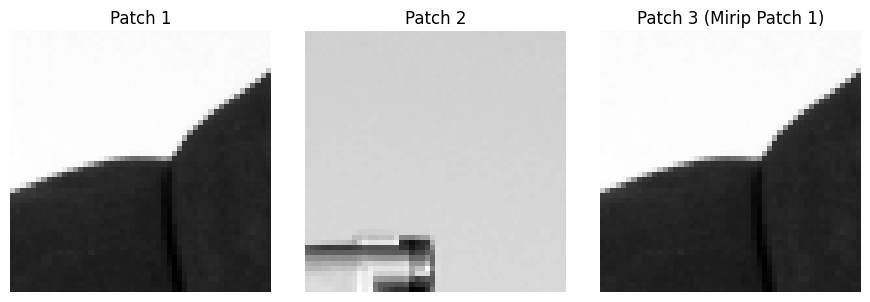

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] # Patch dari lokasi berbeda
patch3 = patch1 + 0.1 # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1) # pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_12_12 = distance.euclidean(vec1, vec2)
dist_12_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_11_12 = distance.cityblock(vec1, vec2)
dist_11_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara patch 1 dan Patch 2: {dist_12_12: .4f}")
print(f"Jarak Euclidean antara patch 1 dan Patch 3: {dist_12_13: .4f}")
print(f"Jarak Manhattan antara patch 1 dan Patch 2: {dist_11_12: .4f}")
print(f"Jarak Manhattan antara patch 1 dan Patch 3: {dist_11_13: .4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffe): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


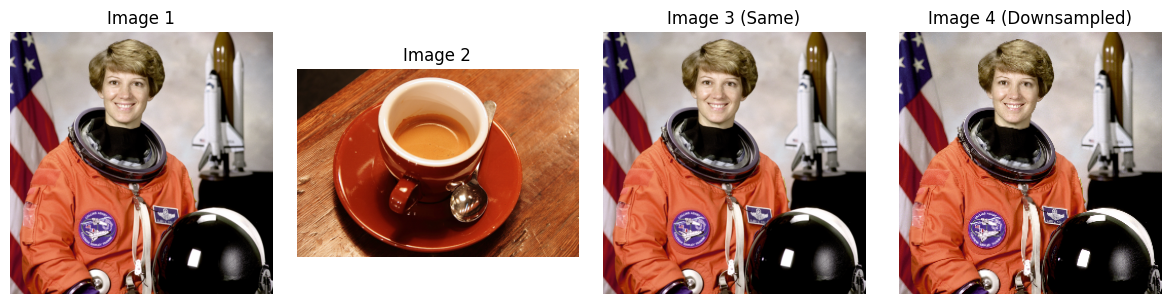

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
  img_uint8 = img_as_ubyte(image)
  hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
  hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
  hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

  # Gabungkan histogram R, G, B menjadi satu vektor fitur
  hist_combined = np.concatenate((hist_r, hist_g, hist_b))
  # Normalisasi (opsional, tapi sering dilakukan)
  hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
  return hist_combined

# 1. Muat dua citra berwarna
try:
  # Gunakan citra berbeda dari skimage atau file Anda
  image1 = data.astronaut()
  image2 = data.coffee() # Citra yang berbeda
  image3 = data.astronaut() # Citra yang sama (untuk perbandingan)
  image4 = image1[::2, ::2, :] # Versi downsampled dari image 1
except Exception as e:
  print(f"Gagal memuat data skimage: {e}. Meembuat citra dummy.")
  image1 = np.random.rand(100, 100, 3)
  image2 = np.random.rand(100, 100, 3) * 0.5
  image3 = image1.copy()
  image4 = image1[::2, ::2, :]

# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - Cosine Distance)
# scipy.spatial.distance.cosine menghitung jarak (1 - similarity)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffe): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

# Visualisasi (opsional)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')
axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')
axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')
axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()




## Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2949
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


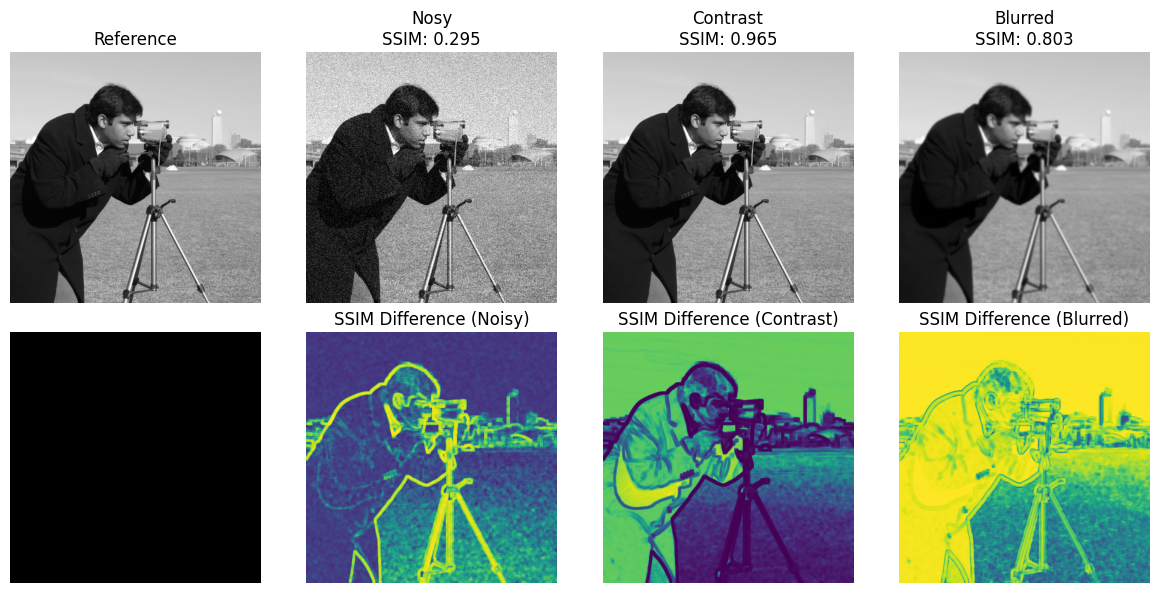

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
# a) Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()

# b) Citra dengan nouse Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
# c) Citra dengan kontras berbeda (contoh: dikalikan skalar)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
# d) Citra yang di-blur
from skimage.filters import gaussian
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None) # channel_axis=None jika grayscale

# 3. Hitung SSIM antara citra referensi dan citra terdistorsi
# pastikan dimensi citra sama jika diperlukan
# SSIM memerlukan data_range
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)
# 'full=True' mengembalikan citra perbedaan SSIM juga

# 4. Tampilkan hasil SSIM dan citra perbedaan SSIM juga
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray');
ax[0].set_title('Reference');
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray');
ax[1].set_title(f'Nosy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray');
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray');
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}');
ax[3].axis('off')

# Menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray');
ax[4].set_title('');
ax[4].axis('off') # Placeholder

ax[5].imshow(diff_noisy, cmap='viridis');
ax[5].set_title('SSIM Difference (Noisy)');
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference (Contrast)');
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()


## Praktikum 4. Penerapan Template Matching

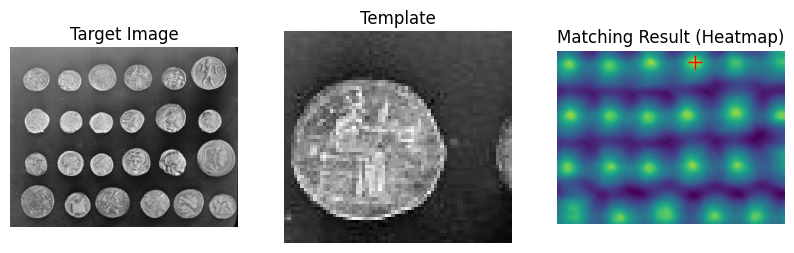

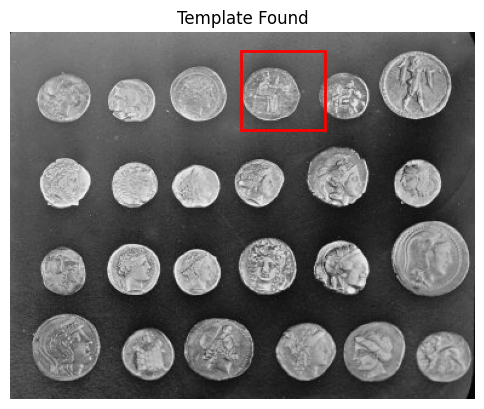

Template ditemukan di koordinat (x, y): (190, 15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()
# Ambil salah satu koin sebagai template (sesuaikan koordinat jika perlu)
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
# np.argmax menemukan indeks linear, unravel_index mengubahnnya ke koordinat 2D
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1] # Koordinat (x,y) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching (opsional)
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10) # y, x karena ij adalah (row, col)

# Menampilkan kotak di lokasi terbaik pada citra asli (di plot terpisah agar lebih jelas)
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

## Prakutikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana


Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


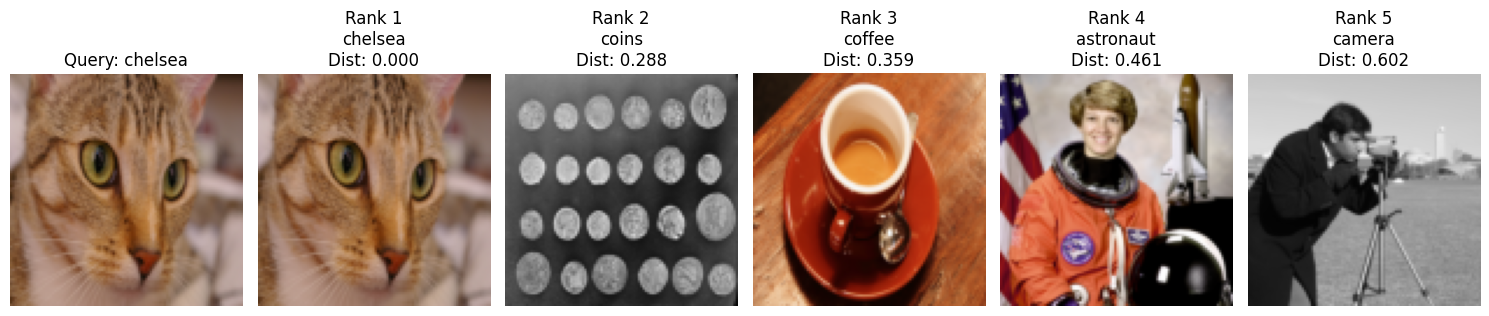

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    # Pastikan input float [0,1] dikonversi ke uint8 [0,255]
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)  # Hindari pembagian dengan nol

    return hist_combined

# 1. Siapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Jika grayscale, ubah ke RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih satu citra sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 2. Hitung jarak cosine antara query dan semua citra
distances = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 3. Urutkan berdasarkan kemiripan (jarak kecil = lebih mirip)
sorted_indices = np.argsort(distances)

# 4. Visualisasi hasil
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


### TUGAS 3

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

=== Hasil Retrieval Berdasarkan Histogram RGB (Cosine) ===
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


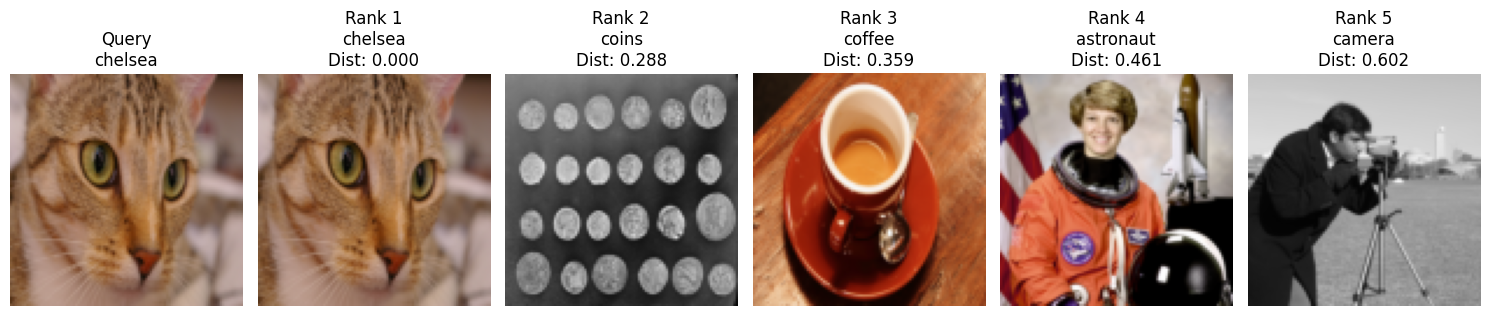


=== Hasil Retrieval Berdasarkan Mean RGB (Euclidean) ===
Rank 1: chelsea (Distance: 0.00)
Rank 2: astronaut (Distance: 12.78)
Rank 3: coffee (Distance: 45.00)
Rank 4: camera (Distance: 49.42)
Rank 5: coins (Distance: 53.81)


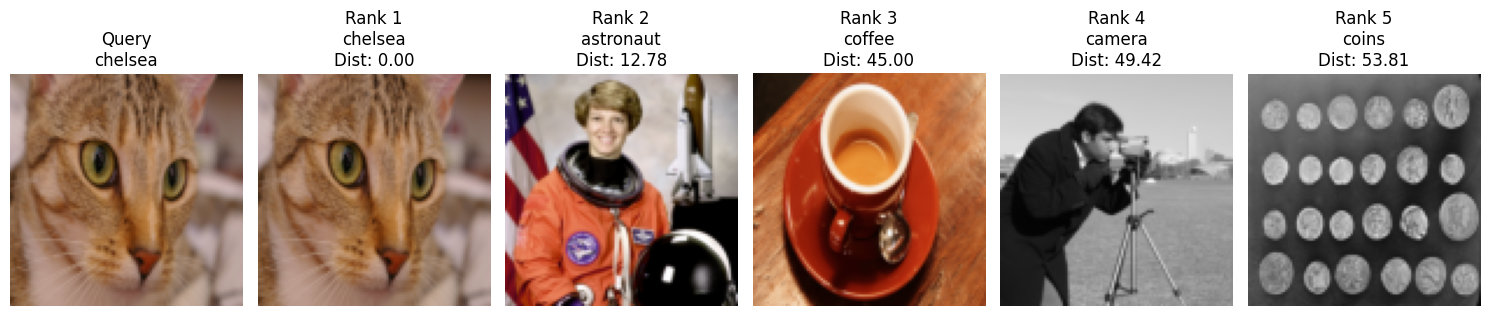

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined

# Fungsi hitung mean RGB
def calculate_rgb_mean(image):
    if image.dtype == float:
        image = img_as_ubyte(image)
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# 1. Siapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []
database_means = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Jika grayscale, ubah ke RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        database_means.append(calculate_rgb_mean(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih satu citra sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]
query_mean = database_means[query_index]

# 2a. Hitung jarak COSINE antara histogram query dan database
distances_hist = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances_hist.append(dist)

# 2b. Hitung jarak EUCLIDEAN antara mean RGB query dan database
distances_mean = []
for mean in database_means:
    dist = np.linalg.norm(query_mean - mean)  # Euclidean (L2)
    distances_mean.append(dist)

# 3. Urutkan berdasarkan kemiripan (semakin kecil jarak, semakin mirip)
sorted_indices_hist = np.argsort(distances_hist)
sorted_indices_mean = np.argsort(distances_mean)

# 4. Visualisasi hasil - Histogram
print("\n=== Hasil Retrieval Berdasarkan Histogram RGB (Cosine) ===")
fig1, axes1 = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))
axes1[0].imshow(query_image)
axes1[0].set_title(f"Query\n{query_image_name}")
axes1[0].axis('off')

for i, idx in enumerate(sorted_indices_hist):
    ax = axes1[i + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances_hist[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances_hist[idx]:.3f})")

plt.tight_layout()
plt.show()

# 5. Visualisasi hasil - Mean RGB
print("\n=== Hasil Retrieval Berdasarkan Mean RGB (Euclidean) ===")
fig2, axes2 = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))
axes2[0].imshow(query_image)
axes2[0].set_title(f"Query\n{query_image_name}")
axes2[0].axis('off')

for i, idx in enumerate(sorted_indices_mean):
    ax = axes2[i + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances_mean[idx]:.2f}")
    ax.axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances_mean[idx]:.2f})")

plt.tight_layout()
plt.show()


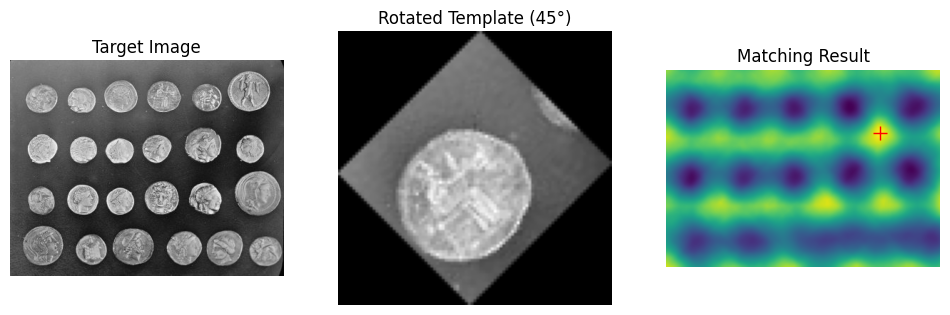

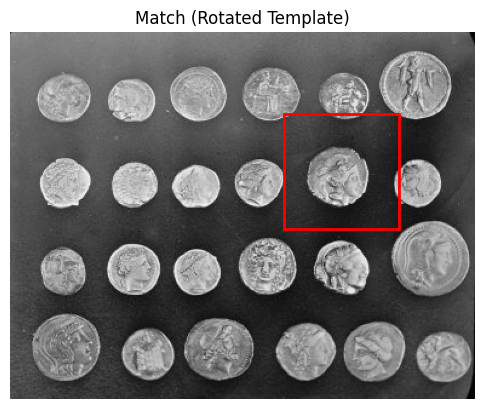

Template hasil rotasi ditemukan di koordinat (x, y): (226, 67)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate

# Muat citra target dan template
image = data.coins()
template = image[15:80, 190:260]

# Rotasi template 45 derajat
rotated_template = rotate(template, angle=45, resize=True)

# Matching dengan template yang diputar
result = match_template(image, rotated_template)

# Temukan lokasi terbaik
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

# Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

ax[1].imshow(rotated_template, cmap='gray')
ax[1].set_title('Rotated Template (45°)')
ax[1].axis('off')

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result')
ax[2].plot(x, y, 'r+', markersize=10)
ax[2].axis('off')

# Tampilkan lokasi pada citra asli
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.imshow(image, cmap='gray')
ax2.set_title('Match (Rotated Template)')
ax2.axis('off')
h, w = rotated_template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', linewidth=2)
ax2.add_patch(rect)

plt.show()

print(f"Template hasil rotasi ditemukan di koordinat (x, y): ({x}, {y})")
